# Group - NULL VALUE



# MODULE - A

### This includes the report at the end of all code blocks, also the video link

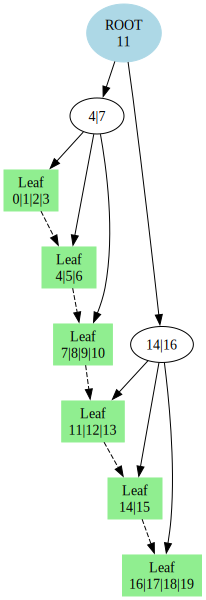

In [1]:
from database.bplustree import BPlusTree

tree = BPlusTree()

import random

keys = list(range(20))
random.shuffle(keys)

for k in keys:
    tree.insert(k, k)

tree.visualize_tree()

In [2]:
from database.performance import PerformanceAnalyzer

sizes = range(100, 10000, 1000)

bpt_insert, bf_insert = [], []
bpt_search, bf_search = [], []
bpt_range, bf_range = [], []
bpt_delete, bf_delete = [], []
bpt_mem, bf_mem = [], []

for n in sizes:
    pa = PerformanceAnalyzer(n,runs=10)

    i1, i2 = pa.test_insert()
    s1, s2 = pa.test_search()
    r1, r2 = pa.test_range()
    d1, d2 = pa.test_delete()
    m1, m2 = pa.memory_usage()
    
    bpt_mem.append(m1)
    bf_mem.append(m2)

    bpt_insert.append(i1)
    bf_insert.append(i2)

    bpt_search.append(s1)
    bf_search.append(s2)

    bpt_range.append(r1)
    bf_range.append(r2)

    bpt_delete.append(d1)
    bf_delete.append(d2)

    print(f"Done for n={n}")

Done for n=100
Done for n=1100
Done for n=2100
Done for n=3100
Done for n=4100
Done for n=5100
Done for n=6100
Done for n=7100
Done for n=8100
Done for n=9100


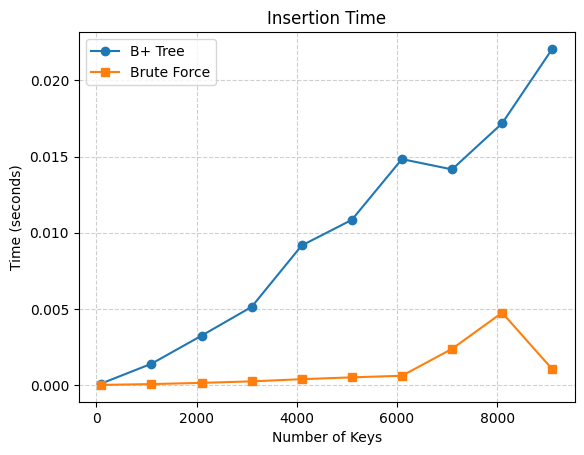

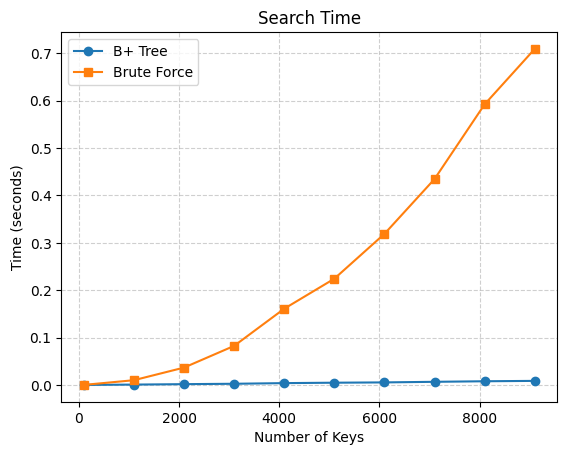

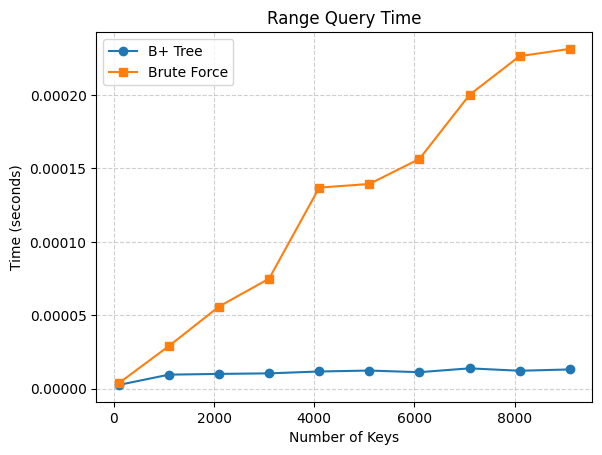

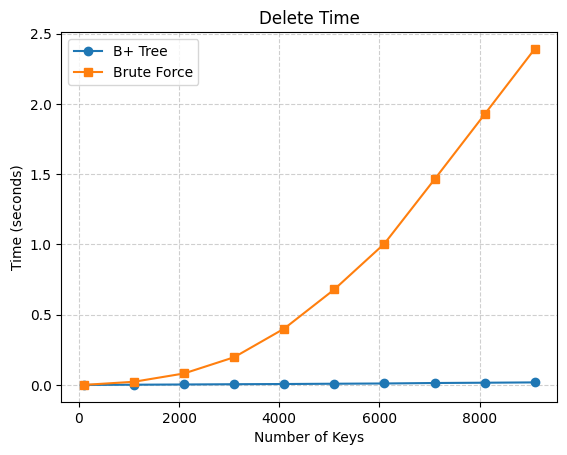

In [ ]:
import matplotlib.pyplot as plt

def plot_graph(x, y1, y2, title):
    plt.figure()
    plt.plot(x, y1, marker='o', label="B+ Tree")
    plt.plot(x, y2, marker='s', label="Brute Force")

    plt.xlabel("Number of Keys")
    plt.ylabel("Time (seconds)")
    plt.title(title)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

plot_graph(sizes, bpt_insert, bf_insert, "Insertion Time")
plot_graph(sizes, bpt_search, bf_search, "Search Time")
plot_graph(sizes, bpt_range, bf_range, "Range Query Time")
plot_graph(sizes, bpt_delete, bf_delete, "Delete Time")

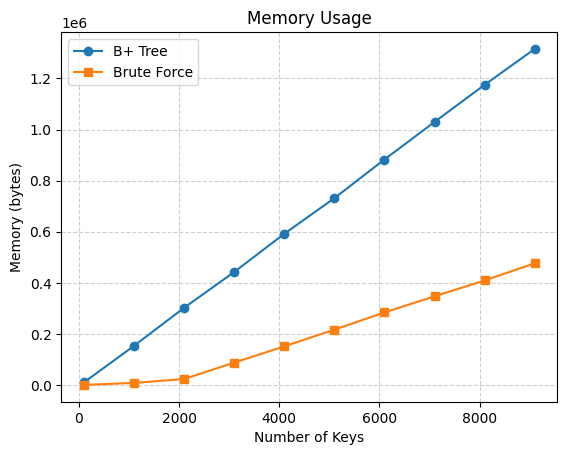

In [4]:
def plot_memory(x, y1, y2):
    plt.figure()
    plt.plot(x, y1, marker='o', label="B+ Tree")
    plt.plot(x, y2, marker='s', label="Brute Force")

    plt.xlabel("Number of Keys")
    plt.ylabel("Memory (bytes)")  
    plt.title("Memory Usage")

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

plot_memory(sizes, bpt_mem, bf_mem)

In [5]:
import pandas as pd

df = pd.DataFrame({
    "n": list(sizes),
    "Insert_BPT": bpt_insert,
    "Insert_BF": bf_insert,
    "Search_BPT": bpt_search,
    "Search_BF": bf_search,
    "Range_BPT": bpt_range,
    "Range_BF": bf_range,
    "Delete_BPT": bpt_delete,
    "Delete_BF": bf_delete,
    "Memory_BPT": bpt_mem,
    "Memory_BF": bf_mem
})

df

,n,Insert_BPT,Insert_BF,Search_BPT,Search_BF,Range_BPT,Range_BF,Delete_BPT,Delete_BF,Memory_BPT,Memory_BF
0,100,0.000100,0.000006,0.000045,0.000081,0.000002,0.000004,0.000098,0.000199,10672,1040
1,1100,0.001396,0.000062,0.000741,0.010017,0.000009,0.000029,0.001603,0.022495,153672,8928
2,2100,0.003237,0.000141,0.001670,0.036620,0.000010,0.000056,0.003198,0.081672,302528,23904
3,3100,0.005129,0.000240,0.002469,0.082430,0.000010,0.000075,0.005130,0.197042,442480,88440
4,4100,0.009160,0.000383,0.003840,0.160875,0.000012,0.000137,0.006539,0.400937,591912,151784
5,5100,0.010842,0.000503,0.004721,0.224200,0.000012,0.000139,0.008588,0.679752,731464,217288
6,6100,0.014829,0.000607,0.005363,0.318828,0.000011,0.000156,0.010339,1.005408,882640,284400
7,7100,0.014153,0.002373,0.006606,0.434581,0.000014,0.000200,0.013775,1.462871,1029632,347728
8,8100,0.017176,0.004749,0.007785,0.592280,0.000012,0.000227,0.015773,1.925953,1174936,409536
9,9100,0.022062,0.001040,0.008570,0.709186,0.000013,0.000231,0.018062,2.391081,1315176,476672


# Report

## Introduction

In database systems, storing and retrieving data efficiently becomes increasingly difficult as the size of the dataset grows. A simple brute-force approach, where data is stored in a list and searched linearly, works for small datasets but becomes very slow for large-scale applications.

To solve this problem, indexing structures are used, and one of the most commonly used structures is the B+ Tree. A B+ Tree is a self-balancing tree that maintains sorted data and allows efficient insertion, deletion, and search operations.

In this assignment, I implemented a lightweight database indexing system using a B+ Tree and compared its performance with a brute-force approach. The goal was to understand how structured indexing improves efficiency, especially for large datasets and range queries.

## Implementation

The system is built in a modular way, with separate components handling the tree structure, database abstraction, and performance analysis.

---

### Project Structure

The project is organized into multiple files for clarity and maintainability:

- `bplustree.py`  
  Contains the core B+ Tree implementation, including all operations such as insertion, search, deletion, and range queries.

- `table.py`  
  Provides a Table abstraction that uses the B+ Tree as an index for storing and retrieving records.

- `db_manager.py`  
  Manages multiple tables, allowing the system to behave like a simple database.

- `bruteforce.py`  
  Implements a basic list-based approach used for performance comparison.

- `performance.py`  
  Contains benchmarking functions to measure insertion, search, range query, deletion, and memory usage.

- `report.ipynb`  
  Used for testing the implementation, running experiments, generating graphs, and documenting results.

---

### B+ Tree Structure

The B+ Tree is implemented using two main classes:
- `BPlusTreeNode` for representing individual nodes  
- `BPlusTree` for handling all operations  

Each node stores:
- Keys (sorted values)
- Values (actual data in leaf nodes)
- Children (for internal nodes)
- Next pointer (links leaf nodes)

The leaf nodes are linked together, which helps in performing efficient range queries.

---

### Core Operations

#### Insertion
When inserting a key, it is placed in the correct sorted position. If a node becomes full, it is split into two nodes, and the first key of the new node is pushed up to the parent. This ensures that the tree remains balanced.

#### Search
Search starts from the root and follows the appropriate child pointers based on key comparisons until it reaches a leaf node. The value is then retrieved from the leaf.

#### Deletion
Deletion was one of the more challenging parts. After removing a key, the tree may become unbalanced. To handle this:
- Keys are borrowed from sibling nodes if possible  
- Otherwise, nodes are merged  
- The root is adjusted if it becomes empty  

#### Range Query
Range queries are efficiently handled by first locating the starting leaf node and then traversing through linked leaf nodes. This avoids repeated traversal from the root.

---

### Database Abstraction

A `Table` class is used to interact with the B+ Tree, and a `DBManager` manages multiple tables. This makes the system behave like a simple database system.

---

### Brute Force Approach

For comparison, a simple list-based structure was implemented. All operations in this approach rely on linear scanning, which becomes inefficient as the dataset grows.

## Performance Analysis

The performance of the B+ Tree was compared with a brute-force approach across different dataset sizes ranging from 100 to around 10,000 keys. Each operation was executed multiple times and averaged to obtain stable results.

### Observations

- **Insertion**:  
  B+ Tree insertion is slightly slower than brute force due to node splitting and balancing overhead. As the dataset size increases, the insertion time for B+ Tree grows gradually, while brute force remains relatively low due to simple append operations.  
  Time Complexity:  
  - B+ Tree → O(log n)  
  - Brute Force → O(1)

- **Search**:  
  B+ Tree search time increases very slowly even as the dataset size grows, showing near logarithmic behavior. In contrast, brute force search time increases rapidly with size due to linear scanning.  
  Time Complexity:  
  - B+ Tree → O(log n)  
  - Brute Force → O(n)

- **Range Query**:  
  B+ Tree performs efficiently for range queries by traversing linked leaf nodes. The time remains almost constant for small ranges even as dataset size increases. Brute force, however, shows a steady increase since it scans all elements.  
  Time Complexity:  
  - B+ Tree → O(log n + k)  
  - Brute Force → O(n)

- **Deletion**:  
  B+ Tree deletion time increases slowly with dataset size due to structured updates and rebalancing. Brute force deletion grows significantly as it requires rebuilding the list after each deletion.  
  Time Complexity:  
  - B+ Tree → O(log n)  
  - Brute Force → O(n)

- **Memory Usage**:  
  Memory usage of the B+ Tree increases linearly with dataset size but remains higher than brute force due to storage of nodes, pointers, and structure overhead. Brute force uses less memory as it stores data in a simple list.

### Effect of Increasing Dataset Size

As the dataset size increases:
- B+ Tree operations scale efficiently, with only gradual increases in time.
- Brute force operations show sharp increases, especially for search, range queries, and deletion.
- The performance gap between B+ Tree and brute force becomes more significant at larger sizes.

### Overall Insight

The results clearly show that while B+ Tree has slightly higher insertion cost and memory usage, it provides significantly better performance for search, deletion, and range queries, making it more suitable for large-scale data systems.

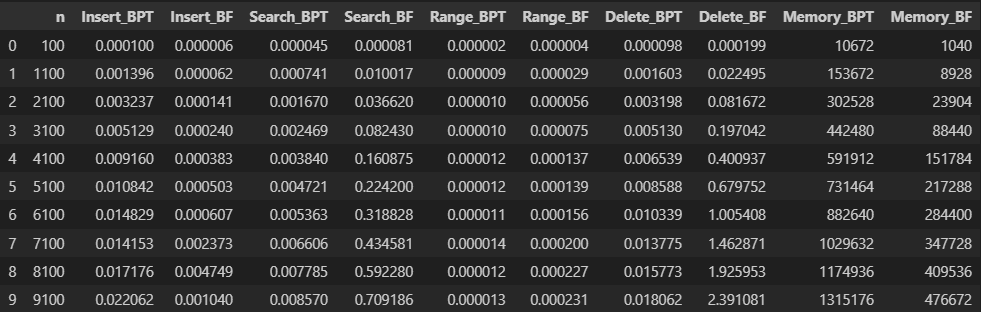

## Visualisation

The structure of the B+ Tree was visualised using Graphviz, which helped in understanding how the tree evolves as elements are inserted.

From the visualisation, it can be observed that:
- The root node acts as the entry point and divides the data into different ranges
- Internal nodes contain separator keys that guide the traversal
- Leaf nodes store the actual data and are linked together

The leaf node linkage is especially important because it allows efficient range queries without repeatedly traversing the tree.

The visualisation made it easier to understand how node splitting and tree balancing work internally.

## Conclusion

In this project, a B+ Tree-based indexing system was implemented and compared with a brute-force approach.

### Key Findings
- B+ Trees perform significantly better for search, deletion, and range queries
- Performance scales efficiently with increasing dataset size
- Insert operations are slightly slower due to balancing overhead
- Memory usage is higher compared to brute force

### Challenges Faced
One of the main challenges was implementing deletion correctly while maintaining the tree structure. Handling borrowing and merging of nodes required careful debugging. Designing a fair range query experiment was also important to ensure meaningful results.

### Future Improvements
- Optimising memory usage of the tree structure
- Extending the implementation to disk-based storage
- Supporting concurrent operations and transactions
- Adding more advanced indexing techniques

Overall, this project helped in understanding how B+ Trees improve database performance and why they are widely used in real-world systems.

## Video Demonstration

[Click here to watch the Module A demonstration](https://drive.google.com/file/d/1nvNY14adI79_OiciEwb0BKM8dLDXPRcJ/view?usp=sharing)